<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
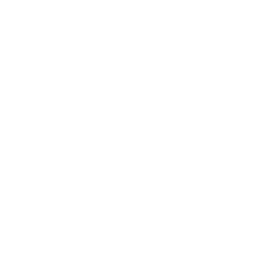
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Curriculum Similarity Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Higher Education / Academic Program Design &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook measures curriculum overlap across a university course
catalog using **PROC DISTANCE** with **METHOD=DJACCARD** — the Jaccard
*dissimilarity* coefficient, the natural distance for binary
presence/absence data. Each course carries 40 binary flags marking
which accreditation learning outcomes it covers, so the Jaccard distance
between two courses is the share of covered outcomes they do **not**
hold in common (0 = identical outcome sets, 1 = no shared outcome).

The analysis runs in two parts. First, across a 500-course catalog it
profiles outcome-coverage breadth by department (PROC MEANS, PROC FREQ,
a coverage box plot) and flags **under-served** learning outcomes —
those carried by fewer than 10% of a department's courses (a thin-coverage
risk at accreditation renewal). Second, it drills into a focused
10-course panel from the Statistics and Data Science departments,
computes the full pairwise Jaccard-distance matrix, and ranks the closest
course pairs as consolidation-review candidates. The goal is to give a
curriculum committee two concrete artifacts: a ranked list of the most
similar courses and a department-by-outcome coverage map.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binary learning-outcome coverage per course (40 outcome flags) | 500 |
| WORK.PANEL10 | Statistics + Data Science consolidation panel | 10 |

The catalog is synthetic. Outcome flags are drawn with
department-specific probabilities so that disciplines emphasize
different outcome clusters — computer science and mathematics weight the
early outcomes (LO1–LO15), the lab sciences weight the middle band
(LO20–LO35), and data science spreads coverage broadly — giving the
distance analysis realistic structure. The full catalog holds 500
courses across eight departments.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic course learning-outcome matrix
   500 courses x 40 accreditation learning outcomes
   -------------------------------------------------------- */
data work.course_outcomes;
    call streaminit(42);
    array outcomes[40] lo_1 - lo_40;
    array dept_list[8] $15 _temporary_ ('COMP_SCI' 'MATH' 'STATISTICS' 'ENGINEERING' 'BIOLOGY' 'CHEMISTRY' 'PHYSICS' 'DATA_SCI');
    do course_id = 1 to 500;
        course_label = cat('CRS', put(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Course level affects outcome breadth */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Department-specific outcome clusters */
        do lo = 1 to 40;
            base_prob = 0.15;
            /* Dept 1-2 (CS, Math): emphasize outcomes 1-15 */
            if dept_idx <= 2 and lo <= 15 then
                base_prob = 0.4 + course_level * 0.05;
            /* Dept 3-4 (Stats, Eng): emphasize outcomes 10-25 */
            else if dept_idx in (3, 4) and 10 <= lo <= 25 then
                base_prob = 0.35 + course_level * 0.05;
            /* Dept 5-7 (Bio, Chem, Phys): emphasize 20-35 */
            else if dept_idx in (5, 6, 7) and 20 <= lo <= 35 then
                base_prob = 0.38 + course_level * 0.04;
            /* Dept 8 (Data Sci): broad coverage */
            else if dept_idx = 8 then
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        end;
        output;
    end;
    drop dept_idx course_level base_prob lo;
run;

NOTE: DATA work.course_outcomes


NOTE: Wrote work.course_outcomes (500 rows, 44 columns).
NOTE: DATA elapsed:
  wall  0.07 seconds
  cpu   0.07 seconds


In [2]:
/* --------------------------------------------------------
   Generate course catalog metadata
   -------------------------------------------------------- */
data work.course_catalog;
    call streaminit(43);
    array dept_list[8] $15 _temporary_ ('COMP_SCI' 'MATH' 'STATISTICS' 'ENGINEERING' 'BIOLOGY' 'CHEMISTRY' 'PHYSICS' 'DATA_SCI');
    array format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    do course_id = 1 to 500;
        course_label = cat('CRS-', put(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        output;
    end;
    drop dept_idx format_idx;
    format last_offered date9.;
run;

NOTE: DATA work.course_catalog


NOTE: Wrote work.course_catalog (500 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                                  The MEANS Procedure

                                                Analysis Variable : lo_1

                                 N
        department             Obs           Mean
        -----------------------------------------
        BIOLOGY                 61      0.1639344
        CHEMISTRY               73      0.1369863
        COMP_SCI                53      0.3962264
        DATA_SCI                70      0.2285714
        ENGINEERING             61      0.1147541
        MATH                    56      0.5535714
        PHYSICS                 58      0.1551724
        STATISTICS              68      0.1029412
        -----------------------------------------

                                                Analysis Variable : lo_2

                                 N
        department             Obs           Mean
        -----------------------------------------
        BIOLOGY                 61      0.0819672
        CH

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


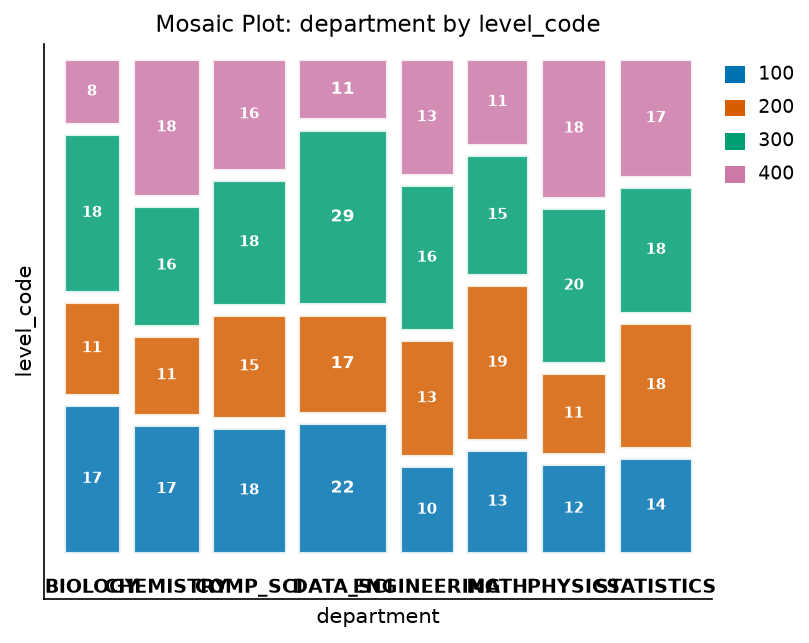

In [3]:
/* --------------------------------------------------------
   Baseline learning outcome coverage by department
   -------------------------------------------------------- */
proc means data=work.course_outcomes mean;
    class department;
    var lo_1 - lo_40;
run;

proc freq data=work.course_catalog;
    tables department * level_code / nopercent norow nocol;
run;

---

NOTE: DATA work.outcome_counts


NOTE: Read 500 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (500 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


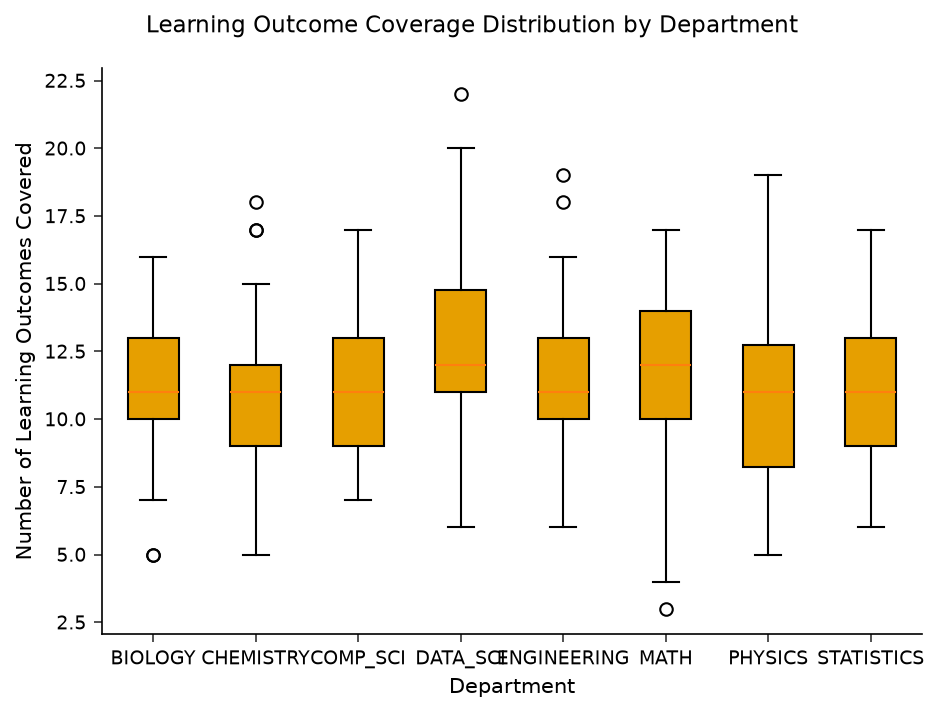

In [4]:
/* --------------------------------------------------------
   Outcome coverage density by department
   -------------------------------------------------------- */
data work.outcome_counts;
    set work.course_outcomes;
    array outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(of outcomes[*]);
run;

proc sgplot data=work.outcome_counts;
    vbox total_outcomes / category=department;
    yaxis label='Number of Learning Outcomes Covered';
    xaxis label='Department';
    title 'Learning Outcome Coverage Distribution by Department';
run;

---

In [5]:
/* --------------------------------------------------------
   Consolidation panel: the first 10 Statistics / Data
   Science courses (the two most quantitatively overlapping
   departments). Re-label them P01-P10 with a sequential
   counter so the square OUT= distance matrix has clean,
   addressable columns, then compute the full pairwise
   Jaccard DISTANCE matrix with METHOD=DJACCARD
   (0 = identical outcome sets, 1 = no shared outcome).
   -------------------------------------------------------- */
data work.panel10;
    set work.course_outcomes(where=(department in ('STATISTICS' 'DATA_SCI')));
    retain seq 0;
    seq + 1;
    if seq > 10 then stop;
    panel_id = cat('P', put(seq, z2.));
    drop seq;
run;

proc print data=work.panel10 noobs label;
    var panel_id course_label department level_code;
    label panel_id = 'Panel ID' course_label = 'Course'
          department = 'Department' level_code = 'Level';
    title 'Consolidation Panel: Statistics and Data Science Courses';
run;

proc distance data=work.panel10
              out=work.panel_dist
              method=djaccard;
    var nominal(lo_1 - lo_40);
    id panel_id;
run;

proc print data=work.panel_dist noobs;
    title 'Pairwise Jaccard Distance Matrix (10 Courses)';
run;

                                Consolidation Panel: Statistics and Data Science Courses                                

Panel ID   Course  Department  Level
P01       CRS0003  DATA_SCI      300
P02       CRS0006  STATISTICS    300
P03       CRS0014  DATA_SCI      300
P04       CRS0015  STATISTICS    300
P05       CRS0017  STATISTICS    200
P06       CRS0019  DATA_SCI      100
P07       CRS0022  STATISTICS    400
P08       CRS0033  DATA_SCI      200
P09       CRS0038  STATISTICS    100
P10       CRS0040  STATISTICS    100

                                Consolidation Panel: Statistics and Data Science Courses                                

                                     Pairwise Jaccard Distance Matrix (10 Courses)                                      

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P01                0  0.8571428571  0.8260869565  0.8095238095  0.7391304348  0

NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Reshape the square distance matrix into a ranked list of
   course pairs. The OUT= distance columns are addressed by
   an explicit name list (P01 P02 ... P10); only the strict
   upper triangle (col > row) is kept so each unordered pair
   appears once and the zero diagonal is skipped. The five
   closest pairs are the consolidation-review candidates.
   -------------------------------------------------------- */
data work.similar_courses;
    set work.panel_dist;
    array d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    length course_a course_b $8;
    course_a = _name_;
    row + 1;
    do col = 1 to 10;
        if col > row then do;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            output;
        end;
    end;
    keep course_a course_b jaccard_dist;
run;

proc means data=work.similar_courses n min q1 median mean max maxdec=3;
    var jaccard_dist;
    title 'Distribution of Pairwise Jaccard Distances (45 Course Pairs)';
run;

proc sort data=work.similar_courses; by jaccard_dist; run;

data work.top_pairs;
    set work.similar_courses;
    pair_rank = _n_;
    if pair_rank <= 5;
run;

proc print data=work.top_pairs noobs label;
    var pair_rank course_a course_b jaccard_dist;
    label pair_rank = 'Rank' course_a = 'Course A'
          course_b = 'Course B' jaccard_dist = 'Jaccard Distance';
    title 'Five Closest Course Pairs (Consolidation Candidates)';
run;

                              Distribution of Pairwise Jaccard Distances (45 Course Pairs)                              

                                                  The MEANS Procedure

 Variable            N     Minimum   Lower Quartile      Median        Mean     Maximum
 --------------------------------------------------------------------------------------
 jaccard_dist       45       0.588            0.756       0.826       0.818       0.962
 --------------------------------------------------------------------------------------

                                  Five Closest Course Pairs (Consolidation Candidates)                                  

Rank  Course A  Course B  Jaccard Distance
   1  P02       P10                  0.588
   2  P03       P04                    0.6
   3  P03       P05                  0.667
   4  P02       P04                  0.684
   5  P02       P07                  0.684



NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                             Under-served Learning Outcomes per Department (coverage < 10%)                             

                                                   The FREQ Procedure

department     Frequency    Percent
------------------------------------
BIOLOGY                6     28.57
CHEMISTRY              4     19.05
COMP_SCI               4     19.05
ENGINEERING            2      9.52
MATH                   1      4.76
PHYSICS                2      9.52
STATISTICS             2      9.52
                              Under-served Outcomes (coverage < 10% of department courses)                              

 Department  Under-served Outcome  Coverage Rate
BIOLOGY      LO40                           4.9%
BIOLOGY      LO18                           6.6%
BIOLOGY      LO05                           8.2%
BIOLOGY      LO02                           8.2%
BIOLOGY      LO17                           8.2%
BIOLOGY      LO39                           9.8%
CHEMISTRY    LO37       

NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 44 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.underserved_outcomes


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.underserved_outcomes (21 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC SORT data=work.underserved_outcomes

NOTE: Read 21 rows from work.underserved_outcomes.
NOTE: Wrote work.underserved_outcomes (21 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=work.underserved_outcomes

NOTE: PROC PRINT completed: 21 observations printed, 3 variables


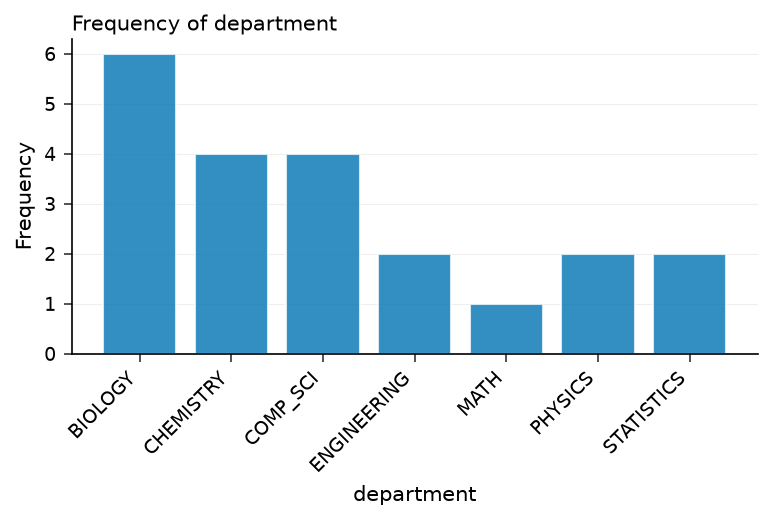

In [7]:
/* --------------------------------------------------------
   Under-served outcomes: learning outcomes carried by only
   a thin slice of a department's courses. PROC MEANS gives
   each binary outcome's coverage RATE within a department
   (the share of that department's courses covering it); a
   rate below 10% flags a thin-coverage accreditation risk.
   -------------------------------------------------------- */
proc means data=work.course_outcomes mean noprint;
    class department;
    var lo_1 - lo_40;
    output out=work.dept_coverage(where=(_type_=1))
        mean=lo_1 - lo_40
        n=n_courses;
run;

data work.underserved_outcomes;
    set work.dept_coverage;
    array cov[40] lo_1 - lo_40;
    length outcome_id $4;
    do lo = 1 to 40;
        outcome_id = cat('LO', put(lo, z2.));
        coverage_rate = round(cov[lo], 0.001);
        if coverage_rate < 0.10 then output;
    end;
    keep department outcome_id coverage_rate n_courses;
run;

proc freq data=work.underserved_outcomes;
    tables department / nocum;
    title 'Under-served Learning Outcomes per Department (coverage < 10%)';
run;

proc sort data=work.underserved_outcomes; by department coverage_rate; run;

proc print data=work.underserved_outcomes noobs label;
    var department outcome_id coverage_rate;
    format coverage_rate percent7.1;
    label department = 'Department' outcome_id = 'Under-served Outcome'
          coverage_rate = 'Coverage Rate';
    title 'Under-served Outcomes (coverage < 10% of department courses)';
run;

---

### Interpretation

**Consolidation panel.** Across the 45 unordered pairs in the
10-course Statistics / Data Science panel, Jaccard distance ranges from
0.588 to 0.962 with a median of 0.826 (mean 0.818). The closest
pair is P02 and P10 at distance 0.588, followed by
P03–P04 at 0.600 and P03–P05 at 0.667. Even the most
similar courses still differ on roughly 59% of their covered
outcomes, so this panel contains **no near-duplicate courses** — there
is no pair a committee could merge outright. The ranked list instead
points to the handful of pairs worth a manual syllabus comparison before
the next catalog cycle; the highest-distance pairs (up to 0.962) confirm
that Statistics and Data Science courses, despite sharing a department
neighborhood, span genuinely distinct outcome sets.

**Under-served outcomes.** Because the full catalog holds 500 courses,
every department offers at least one course touching every one of the 40
outcomes — there are no outright coverage deserts. The accreditation
question at this scale is therefore one of *depth*, not mere presence:
**21 department-by-outcome combinations sit below 10% coverage**, meaning
fewer than one course in ten carries the outcome. The lab-heavy
disciplines are thinnest — **Biology** has the most under-served outcomes
(6, including LO40 at just 4.9% coverage), followed by **Chemistry** and
**Computer Science** (4 each), then **Engineering**, **Physics**, and
**Statistics** (2 each) and **Mathematics** (1). **Data Science**, whose
courses spread coverage broadly by design, has **none** below the
threshold. These thin outcomes are the natural targets for new course
development or cross-listing, while the consolidation list addresses the
opposite problem of redundant effort. Together the two artifacts let the
committee tighten the catalog from both ends — trimming overlap and
shoring up thin coverage — using one set-based distance measure.

---

In [8]:
/* --------------------------------------------------------
   Export the ranked consolidation candidates and the
   department under-served-outcome map for the curriculum
   committee.
   -------------------------------------------------------- */
proc export data=work.similar_courses
    outfile='curriculum_consolidation_candidates.csv'
    dbms=csv replace;
run;

proc export data=work.underserved_outcomes
    outfile='curriculum_underserved_outcomes.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.underserved_outcomes outfile=curriculum_underserved_outcomes.csv

NOTE: Exported 21 rows to curriculum_underserved_outcomes.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>